# Light-Curve Classifier — ZTF Gold (fine taxonomy)

This notebook trains and compares four tabular classifiers on the **ZTF gold**
light-curve features to predict a **fine, 9-class taxonomy** — the thesis's
stretch (sub-typing) objective. It deliberately mirrors the coarse notebook
`lc_classifier_ztf.ipynb` cell-for-cell (same data, same temporal protocol, same
four algorithms, same Optuna budgets) so the coarse and fine results are directly
comparable; it also parallels the "native 14-class" task of
`lc_classifier_plasticc.ipynb` on the simulated side.

**The class set.** The raw gold `fine` column has 25 subtypes with a heavy tail,
and the temporal split interacts badly with it: the Chen+2020 variable stars were
all detected early in ZTF, so several raw classes have **zero validation/test
objects** (Cepheid, Mira, Blazar; DSCT has 1 test object, RRL has 4). Training on
the raw labels would leave those classes unevaluable. Instead we group into an
**ALeRCE-style 9-class taxonomy** — SN subtypes merged into families (SNIa, SNII,
SNIbc, SLSN), Blazar folded into AGN, Mira into LPV, and the thin periodic
pulsators (RRL, DSCT, Cepheid) into VarOther — so every class is present in every
temporal fold, and the grouping mirrors the ALeRCE broker taxonomy the thesis
benchmarks against. The grouping nests cleanly under the coarse classes
(SN | AGN | VS), which §7 exploits.

**Two experiments.**
1. **Flat 9-class classifier** (headline): the four algorithms of the coarse
   notebook — LightGBM, XGBoost, Balanced RF, MLP — with the full tuning protocol.
   See `lc_classifier_ztf.ipynb` §3 / `docs/lc_classifier_ztf.md` for the
   algorithm-selection rationale; it is identical here and not repeated.
2. **Hierarchical coarse→fine comparison** (§7): an ALeRCE-production-style
   two-stage classifier (coarse first, then a per-family fine model), compared
   against the flat winner on the same test fold.

**Protocol in one paragraph.** The split is **temporal** (test is strictly in the
future, ordered by `firstmjd`), so there is no shuffled k-fold anywhere;
hyper-parameters are tuned against a temporal validation set, and the test set is
touched exactly once, by the final tuned models. Trees keep NaNs (missingness is
informative); BRF and the MLP get train-fitted median imputation plus
missing-indicator columns. Imbalance is handled with class weights (LightGBM /
XGBoost), balanced bootstrap (BRF) and train-only random oversampling of real
objects (MLP) — never SMOTE, which would synthesise points that cross the
temporal boundary.

# 0. Setup and configuration

In [1]:
import sys, subprocess

def pip_install(pkgs):
    """Small helper so the notebook is self-bootstrapping on a fresh machine."""
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

# LightGBM / XGBoost / imbalanced-learn / Optuna are the only non-standard deps.
pip_install([
    "lightgbm",
    "xgboost",
    "imbalanced-learn",
    "optuna",
    "scikit-learn",
    "seaborn",
    "matplotlib",
])
print("Dependencies ready.")

Dependencies ready.


In [2]:
import os, json, time, random, warnings, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, log_loss,
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier
import optuna

warnings.filterwarnings("ignore")            # keep the notebook output readable
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("colorblind")
print("Imports ready. seaborn", sns.__version__)

Imports ready. seaborn 0.13.2


C:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Everything the fusion notebook and the alert system need is keyed off the
constants below. `LC_QUICK=1` (an environment variable) runs a fast smoke pass
with tiny Optuna budgets; the shipped default runs the full search. The
`FINE_MAP` dict *is* the taxonomy decision — it is stored verbatim in every model
card so the grouping is auditable.

In [3]:
DATASET   = "ztf_fine"
GOLD      = Path("data/gold")
FIGDIR    = Path("figures/lc") / DATASET     # report figures land here (PNG + PDF)
MODELDIR  = Path("models/lc") / DATASET      # saved models for fusion / alerts
COARSE_MODELDIR = Path("models/lc/ztf")      # coarse-notebook artefacts (read-only)
FIGDIR.mkdir(parents=True, exist_ok=True)
MODELDIR.mkdir(parents=True, exist_ok=True)

# Fixed class order, grouped by coarse family (SN | AGN | VS) so the 9x9
# confusion matrix shows the taxonomy's block structure.
CLASSES = ["SNIa", "SNII", "SNIbc", "SLSN", "AGN", "CV", "EB", "LPV", "VarOther"]
CIDX    = {c: i for i, c in enumerate(CLASSES)}

# Raw gold `fine` label -> grouped class. Generic "SN" (subtype unknown) is
# deliberately absent: those objects cannot be assigned a family and are dropped.
FINE_MAP = {
    "SN Ia": "SNIa", "SN Ia-91T": "SNIa", "SN Ia-91bg": "SNIa",
    "SN Ia-CSM": "SNIa", "SN Iax": "SNIa",
    "SN II": "SNII", "SN IIP": "SNII", "SN IIn": "SNII", "SN IIb": "SNII",
    "SN Ib": "SNIbc", "SN Ic": "SNIbc", "SN Ibc": "SNIbc", "SN Ic-BL": "SNIbc",
    "SLSN": "SLSN",
    "AGN/QSO": "AGN", "Blazar": "AGN",
    "CV": "CV",
    "EB": "EB",
    "LPV": "LPV", "Mira": "LPV",
    "VarOther": "VarOther", "RRL": "VarOther", "DSCT": "VarOther", "Cepheid": "VarOther",
}
PARENT = {"SNIa": "SN", "SNII": "SN", "SNIbc": "SN", "SLSN": "SN",
          "AGN": "AGN",
          "CV": "VS", "EB": "VS", "LPV": "VS", "VarOther": "VS"}
COARSE_CLASSES = ["SN", "AGN", "VS"]         # stage-1 order for §7 (matches coarse notebook)
COARSE_CIDX    = {c: i for i, c in enumerate(COARSE_CLASSES)}
COARSE_COLORS  = {"SN": "#d1495b", "AGN": "#30638e", "VS": "#edae49"}

# Family-shaded palette (SN reds, AGN blue, VS golds) nesting under the coarse one.
FINE_COLORS = {"SNIa": "#d1495b", "SNII": "#e8707f", "SNIbc": "#9c2f3f", "SLSN": "#f2a9b2",
               "AGN": "#30638e",
               "CV": "#edae49", "EB": "#c98a1e", "LPV": "#8f6410", "VarOther": "#f5d08c"}

# Optuna budget per algorithm (GBTs get more trials than BRF / MLP).
QUICK    = os.environ.get("LC_QUICK", "0") == "1"
N_TRIALS = {"lightgbm": 60, "xgboost": 60, "brf": 30, "mlp": 30}
if QUICK:
    N_TRIALS = {k: 3 for k in N_TRIALS}

RUN_DATE = datetime.date.today().isoformat()
print(f"QUICK={QUICK}   trials={N_TRIALS}   run_date={RUN_DATE}")

QUICK=False   trials={'lightgbm': 60, 'xgboost': 60, 'brf': 30, 'mlp': 30}   run_date=2026-07-10


In [4]:
def savefig(fig, name, dpi=300):
    """Save a report figure as both a 300-dpi PNG and a vector PDF."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")

# 1. Load the gold light-curve features

The gold stage of `build_dataset.ipynb` produced five tables joined on `oid`
(the ZTF object id): the ALeRCE feature matrix, the labels, object metadata, and
a pre-computed temporal split. We load the four we need here plus the manifest.
The labels table carries both `coarse` (used by the coarse notebook and by §7's
stage-1) and `fine` (the raw subtype this notebook groups and trains on).

In [5]:
feat = pd.read_parquet(GOLD / "gold_features.parquet")
lab  = pd.read_parquet(GOLD / "gold_labels.parquet")
meta = pd.read_parquet(GOLD / "gold_metadata.parquet")
spl  = pd.read_parquet(GOLD / "gold_splits.parquet")
man  = json.loads((GOLD / "MANIFEST.json").read_text())

print(f"features : {feat.shape[0]:,} objects  x  {feat.shape[1]-1} features")
print(f"labels   : {lab['fine'].nunique()} raw fine classes; "
      f"coarse {lab['coarse'].value_counts().to_dict()}")
print(f"splits   : {spl['split'].value_counts().to_dict()}")

features : 11,826 objects  x  267 features
labels   : 25 raw fine classes; coarse {'SN': 7728, 'VS': 3517, 'AGN': 581}
splits   : {'train': 8278, 'test': 1775, 'val': 1773}


### Integrity check

If the four tables disagree on `oid`, every downstream join silently corrupts the
labels — so we assert the id sets match and that merging does not change the row
count *before* touching any of the data. (This mirrors the check in the gold EDA
and the coarse notebook.)

In [6]:
for name, d in [("labels", lab), ("metadata", meta), ("splits", spl)]:
    assert set(d["oid"]) == set(feat["oid"]), f"oid mismatch: features vs {name}"
assert feat["oid"].is_unique, "duplicate oids in the feature table"

df = (feat.merge(lab[["oid", "coarse", "fine"]], on="oid")
          .merge(spl[["oid", "split", "firstmjd"]], on="oid"))
assert len(df) == len(feat), "a merge changed the row count — keys are not 1:1"
print(f"OK — {len(df):,} objects aligned across all tables")

OK — 11,826 objects aligned across all tables


### Map raw fine labels onto the grouped 9-class taxonomy

`FINE_MAP` converts each of the 25 raw subtypes into its grouped class. The only
label deliberately left out is generic `SN` (a spectroscopic SN with no recorded
subtype — it cannot be placed in a family without guessing), so those objects are
dropped and the count is reported. Two hard assertions protect the protocol:
the fine→coarse nesting must be clean (or §7's hierarchy would be ill-posed), and
every grouped class must appear in every temporal fold (the reason the grouping
exists at all).

In [7]:
df["fine_grouped"] = df["fine"].map(FINE_MAP)
unmapped = df.loc[df["fine_grouped"].isna(), "fine"].value_counts()
assert set(unmapped.index) <= {"SN"}, f"unexpected unmapped fine labels: {unmapped.to_dict()}"
DROPPED_COUNTS = {k: int(v) for k, v in unmapped.items()}
print(f"dropped {int(unmapped.sum())} subtype-unknown objects: {DROPPED_COUNTS}")
df = df[df["fine_grouped"].notna()].reset_index(drop=True)

# The grouped taxonomy must nest cleanly under the coarse classes.
assert (df["fine_grouped"].map(PARENT) == df["coarse"]).all(), "fine->coarse nesting broken"

tab_check = (pd.crosstab(df["fine_grouped"], df["split"])
               .reindex(index=CLASSES, columns=["train", "val", "test"]))
print(tab_check)
assert (tab_check > 0).all().all(), "a grouped class is absent from a split"
print(f"\nOK — {len(df):,} objects, all {len(CLASSES)} classes present in every fold")

dropped 19 subtype-unknown objects: {'SN': 19}
split         train   val  test
fine_grouped                   
SNIa           3347  1093  1084
SNII            995   380   312
SNIbc           242    78    90
SLSN             50    16    22
AGN             403   117    61
CV              504    53    68
EB             1788    10    91
LPV             260     2    14
VarOther        680    19    28

OK — 11,807 objects, all 9 classes present in every fold


### Assemble X / y and drop dead features

Same housekeeping as the coarse notebook: encode the label with the fixed class
order, then drop *dead* features (≥ 99% NaN) deciding **on the training fold
only**. Both are recomputed here rather than copied from the coarse notebook —
dropping the 19 subtype-unknown objects means the fine train fold is not
identical to the coarse one, so neither the dead-feature set nor the split hash
carries over. We cross-check the resulting feature list against the coarse model
card and store both hashes so the fusion contract stays unambiguous.

In [8]:
FEATURES_ALL = [c for c in feat.columns if c != "oid"]
y        = df["fine_grouped"].map(CIDX).to_numpy()
y_coarse = df["coarse"].map(COARSE_CIDX).to_numpy()      # stage-1 target for §7
masks = {s: (df["split"] == s).to_numpy() for s in ("train", "val", "test")}

# "Dead" = >=99% missing on the TRAIN fold only.
train_na = df.loc[masks["train"], FEATURES_ALL].isna().mean()
DEAD     = train_na[train_na >= 0.99].index.tolist()
FEATURES = [c for c in FEATURES_ALL if c not in DEAD]
X = df[FEATURES]
print(f"dropped {len(DEAD)} dead (>=99% NaN) features  ->  {len(FEATURES)} used")

# Diagnostic: how does the feature set compare with the coarse notebook's contract?
coarse_card = json.loads((COARSE_MODELDIR / "lightgbm" / "model_card.json").read_text())
diff = set(coarse_card["feature_names"]) ^ set(FEATURES)
print(f"feature-set difference vs coarse card: {sorted(diff) if diff else 'none'}")

# Convenience handles for each split (+ a train+val set for the final refit).
Xtr, ytr = X[masks["train"]], y[masks["train"]]
Xva, yva = X[masks["val"]],   y[masks["val"]]
Xte, yte = X[masks["test"]],  y[masks["test"]]
Xtrval   = pd.concat([Xtr, Xva]); ytrval = np.concatenate([ytr, yva])

# A short, deterministic hash of the split membership — stored in each model card.
# It differs from the coarse notebook's hash by construction (19 objects dropped),
# so the coarse hash is kept alongside as a lineage pointer.
import hashlib
SPLIT_HASH = hashlib.sha1(
    pd.util.hash_pandas_object(df[["oid", "split"]], index=True).values.tobytes()
).hexdigest()[:12]
COARSE_SPLIT_HASH = coarse_card["split_hash"]
print("split sizes:", {s: int(m.sum()) for s, m in masks.items()},
      f" hash: {SPLIT_HASH}  (coarse: {COARSE_SPLIT_HASH})")

dropped 25 dead (>=99% NaN) features  ->  242 used
feature-set difference vs coarse card: none
split sizes: {'train': 8269, 'val': 1768, 'test': 1770}  hash: 0d968b35aa03  (coarse: 65e15eed88f2)


**Observations.**
- The fine task is **much more imbalanced** than the coarse one: SNIa dominates
  with ~3.3k training objects while SLSN has 50 — a ~67× spread (vs ~13× coarse).
  Macro-F1 remains the headline metric precisely because it weights SLSN as much
  as SNIa.
- The val and test folds are *future* objects, so a model that merely memorises
  the training epoch will be exposed here.

# 2. Pre-modelling EDA

## 2.1 Class balance per split

fine_grouped  SNIa  SNII  SNIbc  SLSN  AGN   CV    EB  LPV  VarOther
split                                                               
train         3347   995    242    50  403  504  1788  260       680
val           1093   380     78    16  117   53    10    2        19
test          1084   312     90    22   61   68    91   14        28

train imbalance ratio (max/min): 66.9x

val support per class (motivates the §5.3 tuning caveat):
{'SNIa': 1093, 'SNII': 380, 'SNIbc': 78, 'SLSN': 16, 'AGN': 117, 'CV': 53, 'EB': 10, 'LPV': 2, 'VarOther': 19}


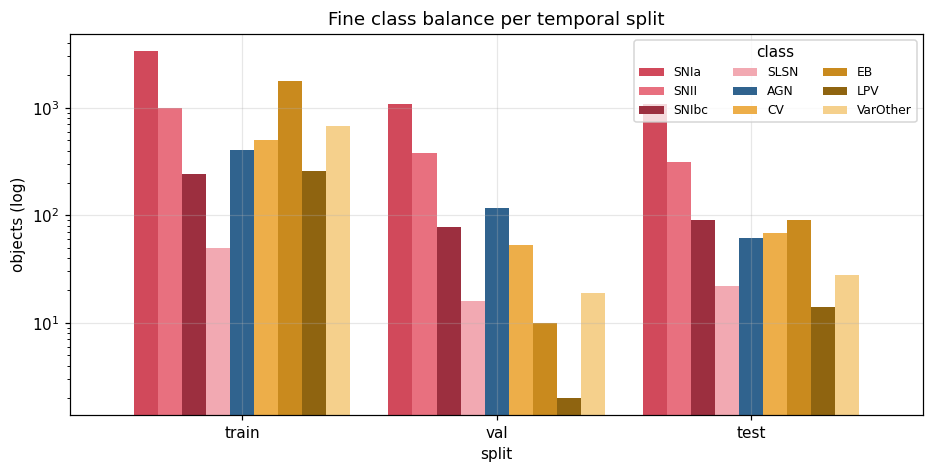

In [9]:
tab = (df.assign(fine_grouped=pd.Categorical(df["fine_grouped"], CLASSES))
         .groupby(["split", "fine_grouped"]).size().unstack()
         .loc[["train", "val", "test"], CLASSES])
imb = tab.loc["train"].max() / tab.loc["train"].min()
print(tab)
print(f"\ntrain imbalance ratio (max/min): {imb:.1f}x")
print(f"\nval support per class (motivates the §5.3 tuning caveat):\n{tab.loc['val'].to_dict()}")

fig, ax = plt.subplots(figsize=(10, 4.5))
tab.plot(kind="bar", ax=ax, width=0.85, color=[FINE_COLORS[c] for c in CLASSES])
ax.set_yscale("log")                         # counts span 2 (LPV val) to 3347 (SNIa train)
ax.set_ylabel("objects (log)"); ax.set_xlabel("split")
ax.set_title("Fine class balance per temporal split")
ax.tick_params(axis="x", rotation=0); ax.legend(title="class", ncol=3, fontsize=8)
savefig(fig, "01_class_balance"); plt.show()

**Observations.**
- The temporal split is **not stratified** — and it shows. The variable-star
  subtypes (all from the early-ZTF Chen+2020 catalogue) sit almost entirely in
  the training fold: EB has 1,788 train objects but only 10 in val; LPV has 2 val
  objects. The SN families, arriving continuously, are far more even.
- This is a property of the deployment-faithful protocol, not a bug: a broker
  really would see mostly old, well-known variables at training time and a
  transient-dominated future. It does make the val fold a noisy judge for the
  thinnest classes — quantified in §5.3.

## 2.2 Feature missingness

mean feature missingness (train): 26.6%
features >50% missing: 69 / 242


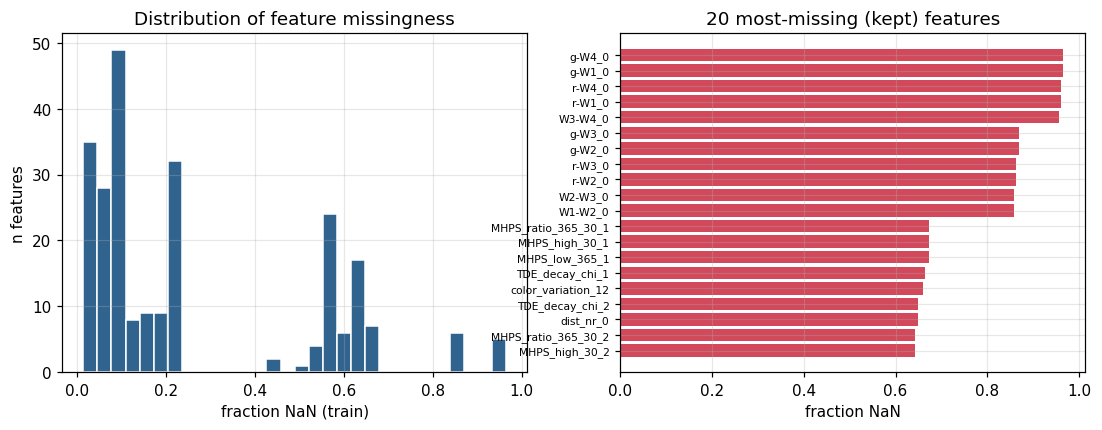

In [10]:
na = Xtr.isna().mean().sort_values(ascending=False)
print(f"mean feature missingness (train): {na.mean():.1%}")
print(f"features >50% missing: {(na > 0.5).sum()} / {len(na)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(na.values, bins=30, color="#30638e", edgecolor="white")
axes[0].set_xlabel("fraction NaN (train)"); axes[0].set_ylabel("n features")
axes[0].set_title("Distribution of feature missingness")
top = na.head(20)[::-1]
axes[1].barh(range(len(top)), top.values, color="#d1495b")
axes[1].set_yticks(range(len(top))); axes[1].set_yticklabels(top.index, fontsize=7)
axes[1].set_xlabel("fraction NaN"); axes[1].set_title("20 most-missing (kept) features")
savefig(fig, "02_missingness"); plt.show()

**Observations.**
- Missingness is heavy and, per the gold EDA, *class-dependent* — e.g. period /
  harmonic features are absent for non-periodic transients. That is genuine
  signal, which is exactly why the two tree models are fed the NaNs directly.
- For the fine task this cuts deeper than for the coarse one: within the VS
  family, the periodic-feature availability pattern itself separates EB/LPV from
  CV. The flip side remains a **limitation** — a model can partly learn feature
  *availability* rather than physics.

## 2.3 Univariate relevance — mutual information (top 20)

delta_mjd_fid_2          0.593
LinearTrend_2            0.578
Multiband_period_12      0.551
delta_mjd_fid_1          0.545
Coordinate_x_0           0.522
mean_sharpnr_12          0.518
last_mjd_before_fid_2    0.514
LinearTrend_1            0.503
ulens_chi_2              0.502
SPM_t0_2                 0.499
dtype: float64


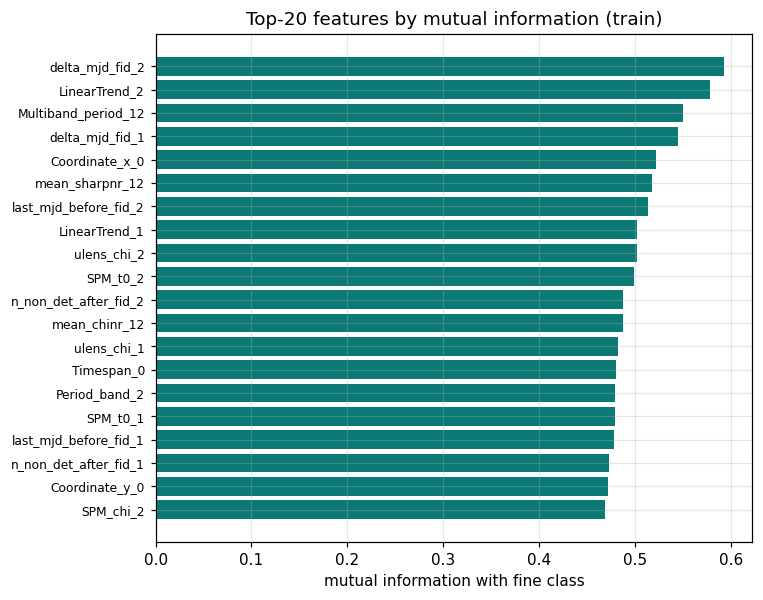

In [11]:
# MI needs complete data, so impute (median) just for this diagnostic.
Xtr_imp = SimpleImputer(strategy="median").fit_transform(Xtr)
mi = mutual_info_classif(Xtr_imp, ytr, random_state=SEED)
mi_s = pd.Series(mi, index=FEATURES).sort_values(ascending=False)
print(mi_s.head(10).round(3))

fig, ax = plt.subplots(figsize=(7, 6))
top = mi_s.head(20)[::-1]
ax.barh(range(len(top)), top.values, color="#0b7a75")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel("mutual information with fine class")
ax.set_title("Top-20 features by mutual information (train)")
savefig(fig, "03_mutual_information"); plt.show()

**Observations.**
- The same amplitude / colour / variability-timescale descriptors that led the
  coarse task lead here, joined by the SPM (supernova parametric model) shape
  parameters — expected, since the fine task must now separate SN families by
  light-curve shape, not just "is it a supernova".
- No single feature dominates, which again favours an additive tree ensemble
  over many weak features.

## 2.4 Feature correlation structure

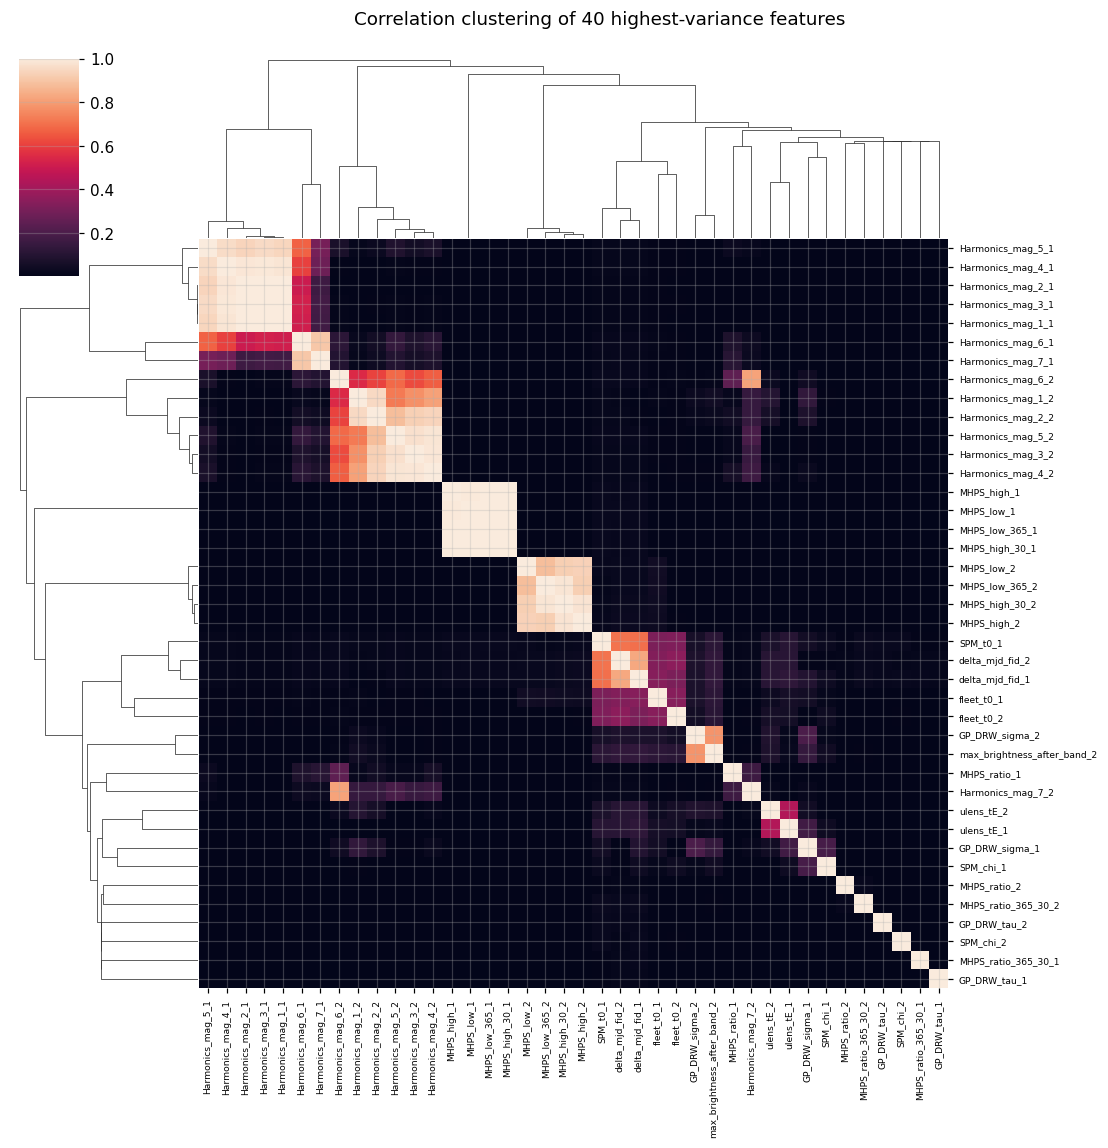

mean |correlation| off-diagonal: 0.069


In [12]:
# 40 highest-variance features, clustered by absolute correlation.
order = np.argsort(Xtr_imp.std(axis=0))[::-1][:40]
sub = pd.DataFrame(Xtr_imp[:, order], columns=[FEATURES[i] for i in order])
corr = sub.corr().abs()
cg = sns.clustermap(corr, cmap="rocket", figsize=(11, 11),
                    xticklabels=True, yticklabels=True)
cg.ax_heatmap.tick_params(labelsize=6)
cg.figure.suptitle("Correlation clustering of 40 highest-variance features", y=1.02)
savefig(cg.figure, "04_correlation_clustermap"); plt.show()

off_diag = corr.values[np.triu_indices_from(corr, 1)]
print(f"mean |correlation| off-diagonal: {off_diag.mean():.3f}")

**Observations.**
- Clear blocks of highly-correlated features (the g/r band-pair variants and the
  harmonic families). The ALeRCE feature set is deliberately redundant.
- Tree ensembles are **insensitive to correlated inputs** — they simply pick one
  of a correlated group at each split — so no decorrelation / PCA step is needed.

## 2.5 Class separation on three headline features

Nine overlaid histograms are unreadable, so this figure shows a six-class subset:
the four VS classes (where the period/amplitude separation now has to happen
*within* the family) plus SNIa and AGN as anchors. The SN families are compared
on SPM shape features in the write-up instead.

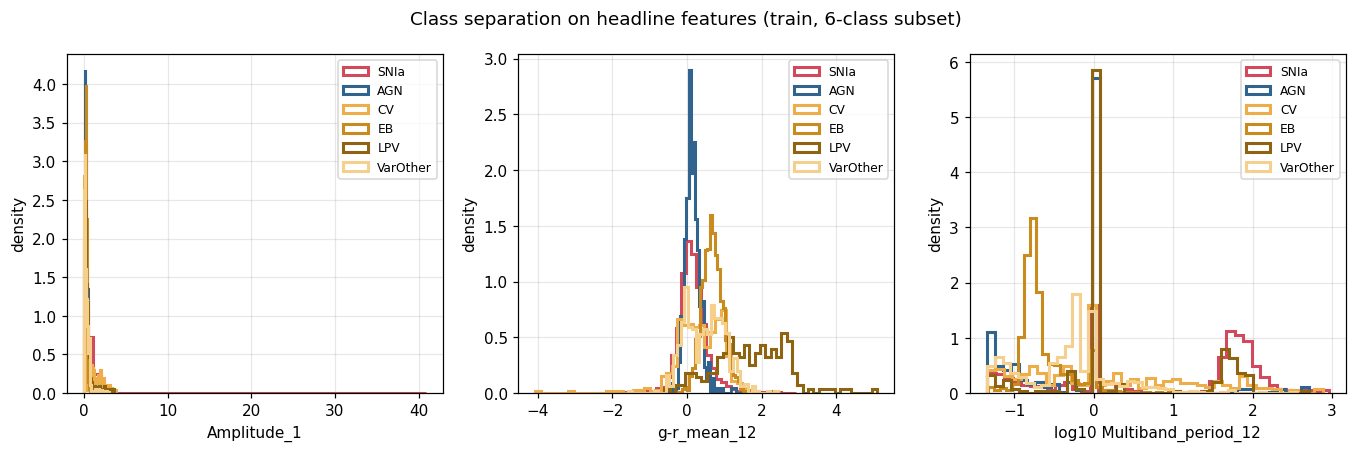

In [13]:
SHOW = ["SNIa", "AGN", "CV", "EB", "LPV", "VarOther"]
HEAD = [h for h in ["Amplitude_1", "g-r_mean_12", "Multiband_period_12"] if h in df.columns]
fig, axes = plt.subplots(1, len(HEAD), figsize=(5 * len(HEAD), 4))
for ax, name in zip(np.atleast_1d(axes), HEAD):
    for c in SHOW:
        v = df.loc[(df["fine_grouped"] == c) & masks["train"], name].dropna()
        xlab = name
        if name == "Multiband_period_12":          # periods span decades -> log
            v = np.log10(v[v > 0]); xlab = f"log10 {name}"
        ax.hist(v, bins=40, histtype="step", lw=2, density=True,
                color=FINE_COLORS[c], label=c)
    ax.set_xlabel(xlab); ax.set_ylabel("density"); ax.legend(fontsize=8)
fig.suptitle("Class separation on headline features (train, 6-class subset)")
savefig(fig, "05_headline_separation"); plt.show()

**Observations.**
- **Period** is now the money plot: it must separate the VS subtypes from each
  other — LPV pile up at long periods, EB at short — not just VS from transients.
- CV, which is *not* periodic, separates from EB/LPV on amplitude instead; this
  is exactly the within-family structure the fine task adds over the coarse one.

# 3. Model and evaluation helpers

Four small factory functions, one per algorithm, each returning an *unfitted*
estimator with class-balancing already configured — identical to the coarse
notebook (see there for the full rationale). Two design points, restated once:

- **Missing values.** LightGBM and XGBoost split on NaN directly, so they get the
  raw features. BRF and the MLP cannot, so they are wrapped in a pipeline that
  imputes (median) and adds a missing-indicator column; the MLP additionally
  standard-scales. Every transformer is fit on train only.
- **Imbalance without SMOTE.** LightGBM / XGBoost use class weights; BRF uses its
  per-tree balanced bootstrap; the MLP is balanced by `RandomOverSampler`, which
  *replicates real, train-only* minority objects — no synthetic points cross the
  temporal split. Note the fine task stresses both mechanisms harder than the
  coarse one: BRF's balanced bootstrap now downsamples every class toward SLSN's
  50 train objects, and the MLP's oversampler inflates train to ~9 × 3.3k rows.

In [14]:
ALGORITHMS  = ["lightgbm", "xgboost", "brf", "mlp"]
ALGO_LABELS = {"lightgbm": "LightGBM", "xgboost": "XGBoost", "brf": "BalancedRF", "mlp": "MLP"}

def impute_steps(scale):
    """Median impute + missing-indicator, optionally followed by standard scaling.
    Returned as a flat list so it can be spliced into an imbalanced-learn pipeline."""
    steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("scale", StandardScaler()))
    return steps

def make_model(algo, params=None):
    """Build one class-balanced learner. `params` (from Optuna) overrides defaults.
    For XGBoost, `num_class` defaults to the flat 9-class task; the §7 branch fits
    override it by passing num_class in `params`."""
    params = dict(params or {})
    if algo == "lightgbm":
        base = dict(n_estimators=600, learning_rate=0.05, num_leaves=31,
                    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                    reg_lambda=1.0, min_child_samples=20, objective="multiclass",
                    class_weight="balanced", random_state=SEED, n_jobs=-1, verbosity=-1)
        base.update(params)
        return LGBMClassifier(**base)

    if algo == "xgboost":
        base = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                    min_child_weight=1.0, gamma=0.0, objective="multi:softprob",
                    num_class=len(CLASSES), tree_method="hist", eval_metric="mlogloss",
                    random_state=SEED, n_jobs=-1)
        base.update(params)
        return XGBClassifier(**base)

    if algo == "brf":
        base = dict(n_estimators=400, max_features="sqrt", min_samples_leaf=1,
                    criterion="gini", sampling_strategy="all", replacement=True,
                    bootstrap=False, random_state=SEED, n_jobs=-1)
        pipe = Pipeline(impute_steps(scale=False) +
                        [("clf", BalancedRandomForestClassifier(**base))])
        if params:                       # Optuna passes clf__-prefixed keys for pipelines
            pipe.set_params(**params)
        return pipe

    if algo == "mlp":
        base = dict(hidden_layer_sizes=(128, 64), alpha=1e-4, learning_rate_init=1e-3,
                    batch_size=256, max_iter=300, early_stopping=True,
                    n_iter_no_change=15, validation_fraction=0.1, random_state=SEED)
        pipe = ImbPipeline(impute_steps(scale=True) +
                           [("ros", RandomOverSampler(random_state=SEED)),
                            ("clf", MLPClassifier(**base))])
        if params:
            pipe.set_params(**params)
        return pipe
    raise ValueError(algo)

In [15]:
def class_sample_weights(y):
    """Per-sample weights from balanced class weights (for XGBoost's fit)."""
    classes = np.unique(y)
    w = compute_class_weight("balanced", classes=classes, y=y)
    lut = {int(c): float(wi) for c, wi in zip(classes, w)}
    return np.array([lut[int(v)] for v in y])

def fit_model(model, algo, Xtr, ytr, Xval=None, yval=None):
    """Fit a model, using the temporal val set for early stopping where supported."""
    if algo == "lightgbm":
        cbs, es = [], ([(Xval, yval)] if Xval is not None else None)
        if es is not None:
            cbs = [early_stopping(50, verbose=False), log_evaluation(0)]
        model.fit(Xtr, ytr, eval_set=es, callbacks=cbs)
    elif algo == "xgboost":
        model.set_params(early_stopping_rounds=50 if Xval is not None else None)
        es = [(Xval, yval)] if Xval is not None else None
        model.fit(Xtr, ytr, sample_weight=class_sample_weights(ytr), eval_set=es, verbose=False)
    else:                                            # BRF / MLP pipelines
        model.fit(Xtr, ytr)
    return model

The evaluation helper computes the full metric battery in one place so every
model, at every stage, is scored identically: macro-F1 (primary), balanced
accuracy, accuracy, MCC, macro one-vs-rest ROC-AUC / PR-AUC, log loss, per-class
precision/recall/F1, and both confusion matrices. It defaults to the 9 fine
classes; §7's stage-1 and branch evaluations pass their own `class_names`
explicitly.

In [16]:
def evaluate(y_true, proba, class_names=CLASSES):
    """Return a dict of all metrics for one model on one split."""
    y_true = np.asarray(y_true)
    y_pred = proba.argmax(1)
    labels = list(range(len(class_names)))

    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    per_class = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1,
                              "support": support}, index=class_names)

    out = {
        "macro_f1":          f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy":          accuracy_score(y_true, y_pred),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0),
    }
    ybin = label_binarize(y_true, classes=labels)
    present = ybin.sum(0) > 0                        # guard classes absent from a split
    try:
        out["roc_auc_macro"] = roc_auc_score(ybin[:, present], proba[:, present],
                                             average="macro", multi_class="ovr")
    except ValueError:
        out["roc_auc_macro"] = np.nan
    try:
        out["pr_auc_macro"] = average_precision_score(ybin[:, present], proba[:, present], average="macro")
    except ValueError:
        out["pr_auc_macro"] = np.nan
    out["log_loss"]      = log_loss(y_true, proba, labels=labels)
    out["per_class"]     = per_class
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    out["confusion"]     = cm
    out["confusion_norm"]= np.nan_to_num(cm / cm.sum(1, keepdims=True))
    return out

def scalar_row(ev, name):
    """Flatten an evaluate() result into one comparison-table row."""
    keys = ["macro_f1", "balanced_accuracy", "accuracy", "mcc",
            "weighted_f1", "roc_auc_macro", "pr_auc_macro", "log_loss"]
    return {"model": name, **{k: ev[k] for k in keys}}

# 4. Baseline models

First pass: all four algorithms with sensible, class-balanced defaults (no
tuning). Scored on the **validation** set — the test set stays sealed until §6.

In [17]:
baseline_models, baseline_rows = {}, []
for algo in ALGORITHMS:
    model = fit_model(make_model(algo), algo, Xtr, ytr, Xva, yva)
    ev = evaluate(yva, model.predict_proba(Xva))
    baseline_models[algo] = model
    baseline_rows.append(scalar_row(ev, ALGO_LABELS[algo]))
    print(f"\n===== {ALGO_LABELS[algo]}  (val macro-F1 {ev['macro_f1']:.3f}) =====")
    print(classification_report(yva, model.predict_proba(Xva).argmax(1),
                                labels=list(range(len(CLASSES))),
                                target_names=CLASSES, digits=3, zero_division=0))


===== LightGBM  (val macro-F1 0.566) =====
              precision    recall  f1-score   support

        SNIa      0.874     0.946     0.909      1093
        SNII      0.826     0.711     0.764       380
       SNIbc      0.417     0.064     0.111        78
        SLSN      0.500     0.062     0.111        16
         AGN      0.911     0.966     0.938       117
          CV      0.446     0.774     0.566        53
          EB      0.556     0.500     0.526        10
         LPV      0.500     0.500     0.500         2
    VarOther      0.706     0.632     0.667        19

    accuracy                          0.838      1768
   macro avg      0.637     0.573     0.566      1768
weighted avg      0.826     0.838     0.822      1768




===== XGBoost  (val macro-F1 0.586) =====
              precision    recall  f1-score   support

        SNIa      0.884     0.945     0.914      1093
        SNII      0.827     0.729     0.775       380
       SNIbc      0.500     0.090     0.152        78
        SLSN      1.000     0.062     0.118        16
         AGN      0.933     0.957     0.945       117
          CV      0.390     0.774     0.519        53
          EB      0.625     0.500     0.556        10
         LPV      1.000     0.500     0.667         2
    VarOther      0.688     0.579     0.629        19

    accuracy                          0.842      1768
   macro avg      0.761     0.571     0.586      1768
weighted avg      0.841     0.842     0.828      1768




===== BalancedRF  (val macro-F1 0.360) =====
              precision    recall  f1-score   support

        SNIa      0.910     0.519     0.661      1093
        SNII      0.691     0.471     0.560       380
       SNIbc      0.192     0.359     0.250        78
        SLSN      0.121     0.250     0.163        16
         AGN      0.527     0.923     0.671       117
          CV      0.083     0.755     0.149        53
          EB      0.500     0.100     0.167        10
         LPV      0.200     0.500     0.286         2
    VarOther      0.455     0.263     0.333        19

    accuracy                          0.528      1768
   macro avg      0.409     0.460     0.360      1768
weighted avg      0.766     0.528     0.595      1768




===== MLP  (val macro-F1 0.352) =====
              precision    recall  f1-score   support

        SNIa      0.781     0.694     0.734      1093
        SNII      0.692     0.497     0.579       380
       SNIbc      0.107     0.103     0.105        78
        SLSN      0.333     0.125     0.182        16
         AGN      0.694     0.718     0.706       117
          CV      0.104     0.547     0.174        53
          EB      0.400     0.400     0.400        10
         LPV      0.000     0.000     0.000         2
    VarOther      0.233     0.368     0.286        19

    accuracy                          0.611      1768
   macro avg      0.372     0.384     0.352      1768
weighted avg      0.693     0.611     0.642      1768



In [18]:
baseline_df = pd.DataFrame(baseline_rows).set_index("model").round(3)
baseline_df.sort_values("macro_f1", ascending=False)

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
XGBoost,0.586,0.571,0.842,0.713,0.828,0.959,0.674,0.484
LightGBM,0.566,0.573,0.838,0.705,0.822,0.956,0.640,0.496
BalancedRF,0.360,0.460,0.528,0.395,0.595,0.867,0.499,1.383
MLP,0.352,0.384,0.611,0.378,0.642,0.821,0.372,3.749


**Observations.**
- The classification reports make the thin-class problem visible: LPV and EB have
  val support of only 2 and 10, so their rows are quantised — see the §5.3 caveat.
- As on the coarse task, the **gradient-boosted trees** lead untuned; the fine
  task simply widens the gaps, because the rare classes reward models that can
  exploit informative missingness and interactions with few examples.

# 5. Hyper-parameter tuning (Optuna)

TPE sampler, fixed seed, and — critically — the objective is **macro-F1 on the
temporal validation set**, never a shuffled fold. The search spaces are identical
to the coarse notebook (written out below so they can be lifted into the
methodology chapter).

In [19]:
def suggest_params(algo, trial):
    """Optuna search space per algorithm."""
    if algo == "lightgbm":
        return dict(
            n_estimators     = trial.suggest_int("n_estimators", 200, 1200, step=100),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            num_leaves       = trial.suggest_int("num_leaves", 15, 255, log=True),
            max_depth        = trial.suggest_int("max_depth", 3, 12),
            min_child_samples= trial.suggest_int("min_child_samples", 5, 100),
            subsample        = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
    if algo == "xgboost":
        return dict(
            n_estimators     = trial.suggest_int("n_estimators", 200, 1200, step=100),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth        = trial.suggest_int("max_depth", 3, 12),
            min_child_weight = trial.suggest_float("min_child_weight", 1.0, 20.0),
            subsample        = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            gamma            = trial.suggest_float("gamma", 1e-3, 5.0, log=True),
            reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        )
    if algo == "brf":
        return dict(
            clf__n_estimators   = trial.suggest_int("clf__n_estimators", 200, 800, step=100),
            clf__max_depth      = trial.suggest_categorical("clf__max_depth", [None, 8, 16, 24, 32]),
            clf__max_features   = trial.suggest_categorical("clf__max_features", ["sqrt", "log2", 0.5]),
            clf__min_samples_leaf = trial.suggest_int("clf__min_samples_leaf", 1, 20),
            clf__criterion      = trial.suggest_categorical("clf__criterion", ["gini", "entropy"]),
        )
    if algo == "mlp":
        n_layers = trial.suggest_int("n_layers", 1, 3)
        width    = trial.suggest_categorical("width", [64, 128, 256])
        sizes    = tuple(width for _ in range(n_layers))
        # Optuna records only the raw suggestions (n_layers, width); stash the
        # derived architecture so best_config() can recover it after the study.
        trial.set_user_attr("clf__hidden_layer_sizes", sizes)
        return dict(
            clf__hidden_layer_sizes = sizes,
            clf__alpha              = trial.suggest_float("clf__alpha", 1e-6, 1e-1, log=True),
            clf__learning_rate_init = trial.suggest_float("clf__learning_rate_init", 1e-4, 1e-2, log=True),
            clf__batch_size         = trial.suggest_categorical("clf__batch_size", [128, 256, 512]),
        )
    raise ValueError(algo)

def best_config(study, algo):
    """Resolve a study's best trial into params make_model() can consume directly.
    For the MLP this swaps the raw (n_layers, width) for the derived layer sizes."""
    p = dict(study.best_params)
    if algo == "mlp":
        p.pop("n_layers", None); p.pop("width", None)
        p.update(study.best_trial.user_attrs)     # -> clf__hidden_layer_sizes
    return p

def tune(algo, n_trials):
    """Run a TPE study; objective = macro-F1 on the temporal val set."""
    def objective(trial):
        model = make_model(algo, suggest_params(algo, trial))
        fit_model(model, algo, Xtr, ytr, Xva, yva)
        pred = model.predict_proba(Xva).argmax(1)
        return f1_score(yva, pred, average="macro", labels=list(range(len(CLASSES))), zero_division=0)
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)
    return study

In [20]:
studies, best_params = {}, {}
for algo in ALGORITHMS:
    t0 = time.perf_counter()
    study = tune(algo, N_TRIALS[algo])
    studies[algo], best_params[algo] = study, best_config(study, algo)
    print(f"{ALGO_LABELS[algo]:11s}  best val macro-F1 = {study.best_value:.4f}"
          f"   ({len(study.trials)} trials, {time.perf_counter()-t0:.0f}s)")

LightGBM     best val macro-F1 = 0.5883   (60 trials, 466s)


XGBoost      best val macro-F1 = 0.5897   (60 trials, 1835s)


BalancedRF   best val macro-F1 = 0.4365   (30 trials, 70s)


MLP          best val macro-F1 = 0.4517   (30 trials, 966s)


## 5.1 Optuna convergence

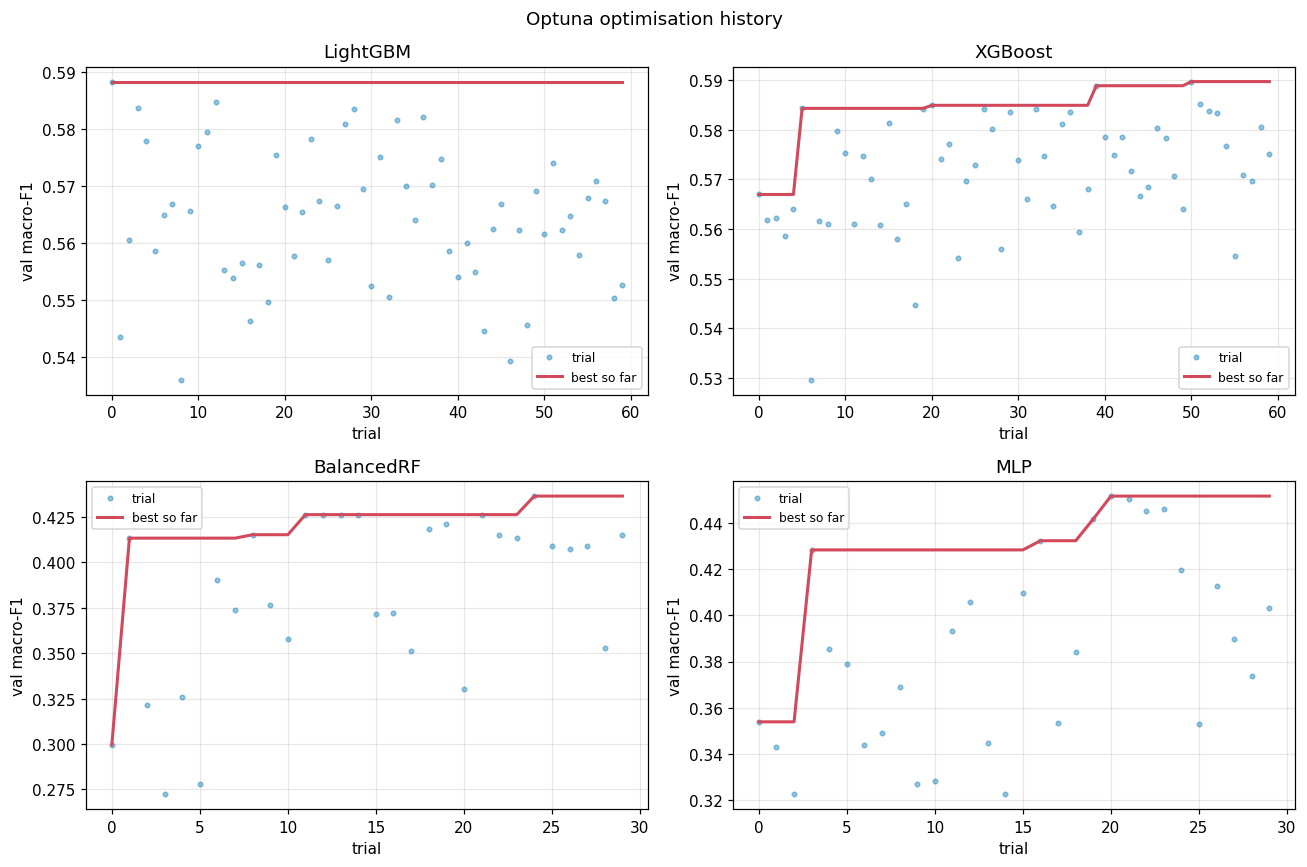

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, algo in zip(axes.ravel(), ALGORITHMS):
    vals = [t.value for t in studies[algo].trials if t.value is not None]
    ax.plot(vals, "o", ms=3, alpha=0.4, label="trial")
    ax.plot(np.maximum.accumulate(vals), "-", color="#d1495b", lw=2, label="best so far")
    ax.set_title(ALGO_LABELS[algo]); ax.set_xlabel("trial"); ax.set_ylabel("val macro-F1")
    ax.legend(fontsize=8)
fig.suptitle("Optuna optimisation history"); fig.tight_layout()
savefig(fig, "06_optuna_history"); plt.show()

**Observations.**
- The GBT studies again converge within the first ~20–30 trials.
- Expect visibly noisier trial values than on the coarse task: part of the
  objective now rests on classes with single-digit val support (next subsection).

## 5.2 Refit on train + val and save

Each tuned configuration is refit on **train + val** (early stopping switched off —
there is no held-out fold left) and written to `models/lc/ztf_fine/<algo>/`. Every
directory gets the fusion / alert-system contract: the fitted model via `joblib`,
the native booster (LightGBM `.txt`, XGBoost `.json`), the tuned params, and a
`model_card.json` recording the feature order, class order, **the FINE_MAP itself**
(so the taxonomy decision travels with the model), the dropped-label counts, and
both split hashes.

In [22]:
import joblib, sklearn, lightgbm, xgboost, imblearn

def package_versions():
    return {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "lightgbm": lightgbm.__version__,
            "xgboost": xgboost.__version__, "imbalanced-learn": imblearn.__version__,
            "optuna": optuna.__version__}

def scalar_metrics(ev):
    return {k: float(v) for k, v in ev.items()
            if k not in ("per_class", "confusion", "confusion_norm")}

def save_model(outdir, model, algo, params, val_ev):
    """Write joblib bundle + native booster + model_card.json (the fusion contract)."""
    outdir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, outdir / "model.joblib")
    native = None
    if algo == "lightgbm":
        model.booster_.save_model(str(outdir / "model.txt")); native = "model.txt"
    elif algo == "xgboost":
        model.get_booster().save_model(str(outdir / "model.json")); native = "model.json"
    card = {
        "algorithm": algo, "dataset": "ztf", "taxonomy": "fine_grouped", "band_variant": "gr",
        "feature_names": FEATURES, "n_features": len(FEATURES),
        "class_names": CLASSES, "n_classes": len(CLASSES),
        "fine_map": FINE_MAP, "parent_map": PARENT,        # the taxonomy decision, verbatim
        "dropped_labels": DROPPED_COUNTS,                  # e.g. {"SN": 19}
        "consumes_nan_natively": algo in ("lightgbm", "xgboost"),
        "split_hash": SPLIT_HASH, "coarse_split_hash": COARSE_SPLIT_HASH,
        "train_date": RUN_DATE, "native_model": native,
        "tuned_params": params, "val_metrics": scalar_metrics(val_ev), "test_metrics": None,
        "package_versions": package_versions(),
    }
    (outdir / "model_card.json").write_text(json.dumps(card, indent=2))
    (outdir / "best_params.json").write_text(json.dumps(params, indent=2))

In [23]:
best_models, val_evals = {}, {}
for algo in ALGORITHMS:
    # Final model: tuned config refit on train+val (this is what fusion loads).
    final = fit_model(make_model(algo, best_params[algo]), algo, Xtrval, ytrval)
    best_models[algo] = final
    # Val metrics for the card come from the same config trained on train-only.
    vmodel = fit_model(make_model(algo, best_params[algo]), algo, Xtr, ytr, Xva, yva)
    val_evals[algo] = evaluate(yva, vmodel.predict_proba(Xva))
    save_model(MODELDIR / algo, final, algo, best_params[algo], val_evals[algo])
    print(f"saved {MODELDIR / algo}   (val macro-F1 {val_evals[algo]['macro_f1']:.3f})")

saved models\lc\ztf_fine\lightgbm   (val macro-F1 0.588)


saved models\lc\ztf_fine\xgboost   (val macro-F1 0.590)


saved models\lc\ztf_fine\brf   (val macro-F1 0.436)


saved models\lc\ztf_fine\mlp   (val macro-F1 0.452)


## 5.3 Caveat — thin classes in the tuning objective

Under the temporal split, **LPV has 2 validation objects and EB has 10**. We keep
all 9 classes in the tuning objective — excluding them would mean the tuner never
sees them at all, and with `zero_division=0` a configuration that never predicts a
thin class pays a consistent, monotone penalty of exactly 1/9 of the macro score,
so nothing is undefined. But the *granularity* is coarse: LPV's val F1 can only
take a handful of values, so up to ~0.11 of val macro-F1 is quantisation noise the
TPE sampler can chase. The table below quantifies how much of each tuned model's
val macro-F1 rests on the two thin classes; §6 then shows the val→test gap. This
is a **reported limitation** of the deployment-faithful protocol, not something we
fix by re-stratifying — the temporal split is the methodological point.

In [24]:
THIN = ["LPV", "EB"]                       # val support 2 and 10
rows = []
for algo in ALGORITHMS:
    pc = val_evals[algo]["per_class"]["f1"]
    rows.append({"model": ALGO_LABELS[algo],
                 "val_macroF1_all9": pc.mean(),
                 "val_macroF1_wo_LPV_EB": pc.drop(index=THIN).mean(),
                 "thin_class_contribution": pc.mean() - pc.drop(index=THIN).mean()})
thin_df = pd.DataFrame(rows).set_index("model").round(4)
thin_df

,val_macroF1_all9,val_macroF1_wo_LPV_EB,thin_class_contribution
model,,,
LightGBM,0.5883,0.5850,0.0033
XGBoost,0.5897,0.6074,-0.0177
BalancedRF,0.4365,0.4898,-0.0533
MLP,0.4517,0.4404,0.0113


# 6. Final evaluation on the test set

The tuned models now see the **future** test objects for the first and only time.

In [25]:
test_evals, test_rows, latency = {}, [], []
for algo in ALGORITHMS:
    proba = best_models[algo].predict_proba(Xte)
    ev = evaluate(yte, proba)
    test_evals[algo] = ev
    test_rows.append(scalar_row(ev, ALGO_LABELS[algo]))

    # time inference (best of 3 runs) — relevant to the real-time alert claim
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        best_models[algo].predict_proba(Xte)
        times.append(time.perf_counter() - t0)
    latency.append({"model": ALGO_LABELS[algo],
                    "per_object_ms": 1e3 * min(times) / len(Xte)})

    # write test metrics back into the saved model card
    card = json.loads((MODELDIR / algo / "model_card.json").read_text())
    card["test_metrics"] = scalar_metrics(ev)
    (MODELDIR / algo / "model_card.json").write_text(json.dumps(card, indent=2))

test_df = pd.DataFrame(test_rows).set_index("model").round(4)
test_df.to_csv(FIGDIR / "test_metrics.csv")
test_df.sort_values("macro_f1", ascending=False)

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
XGBoost,0.7049,0.7255,0.8226,0.7028,0.8230,0.9552,0.7588,0.5493
LightGBM,0.6701,0.6801,0.8175,0.6855,0.8090,0.9558,0.7506,0.5274
BalancedRF,0.5645,0.6877,0.6774,0.5371,0.7100,0.9253,0.6712,1.1480
MLP,0.5523,0.5861,0.7107,0.4905,0.6932,0.8654,0.5795,3.5276


## 6.1 Headline comparison — macro-F1 and balanced accuracy

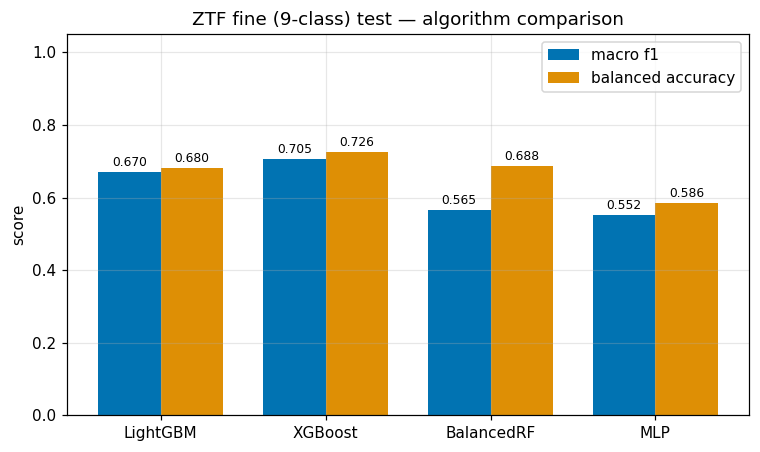

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xpos, w = np.arange(len(test_df)), 0.38
for i, m in enumerate(["macro_f1", "balanced_accuracy"]):
    bars = ax.bar(xpos + (i - 0.5) * w, test_df[m], w, label=m.replace("_", " "))
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax.set_xticks(xpos); ax.set_xticklabels(test_df.index)
ax.set_ylim(0, 1.05); ax.set_ylabel("score")
ax.set_title("ZTF fine (9-class) test — algorithm comparison"); ax.legend()
savefig(fig, "07_macroF1_comparison"); plt.show()

## 6.2 Confusion matrices (row-normalised)

The class order groups the taxonomy's families (SN | AGN | VS), so within-family
confusion shows up as blocks on the diagonal; the white separators mark the family
boundaries. Astrophysically-plausible errors (SNIbc↔SNIa, EB↔VarOther) stay inside
a block; cross-block errors are the expensive ones a broker cares about.

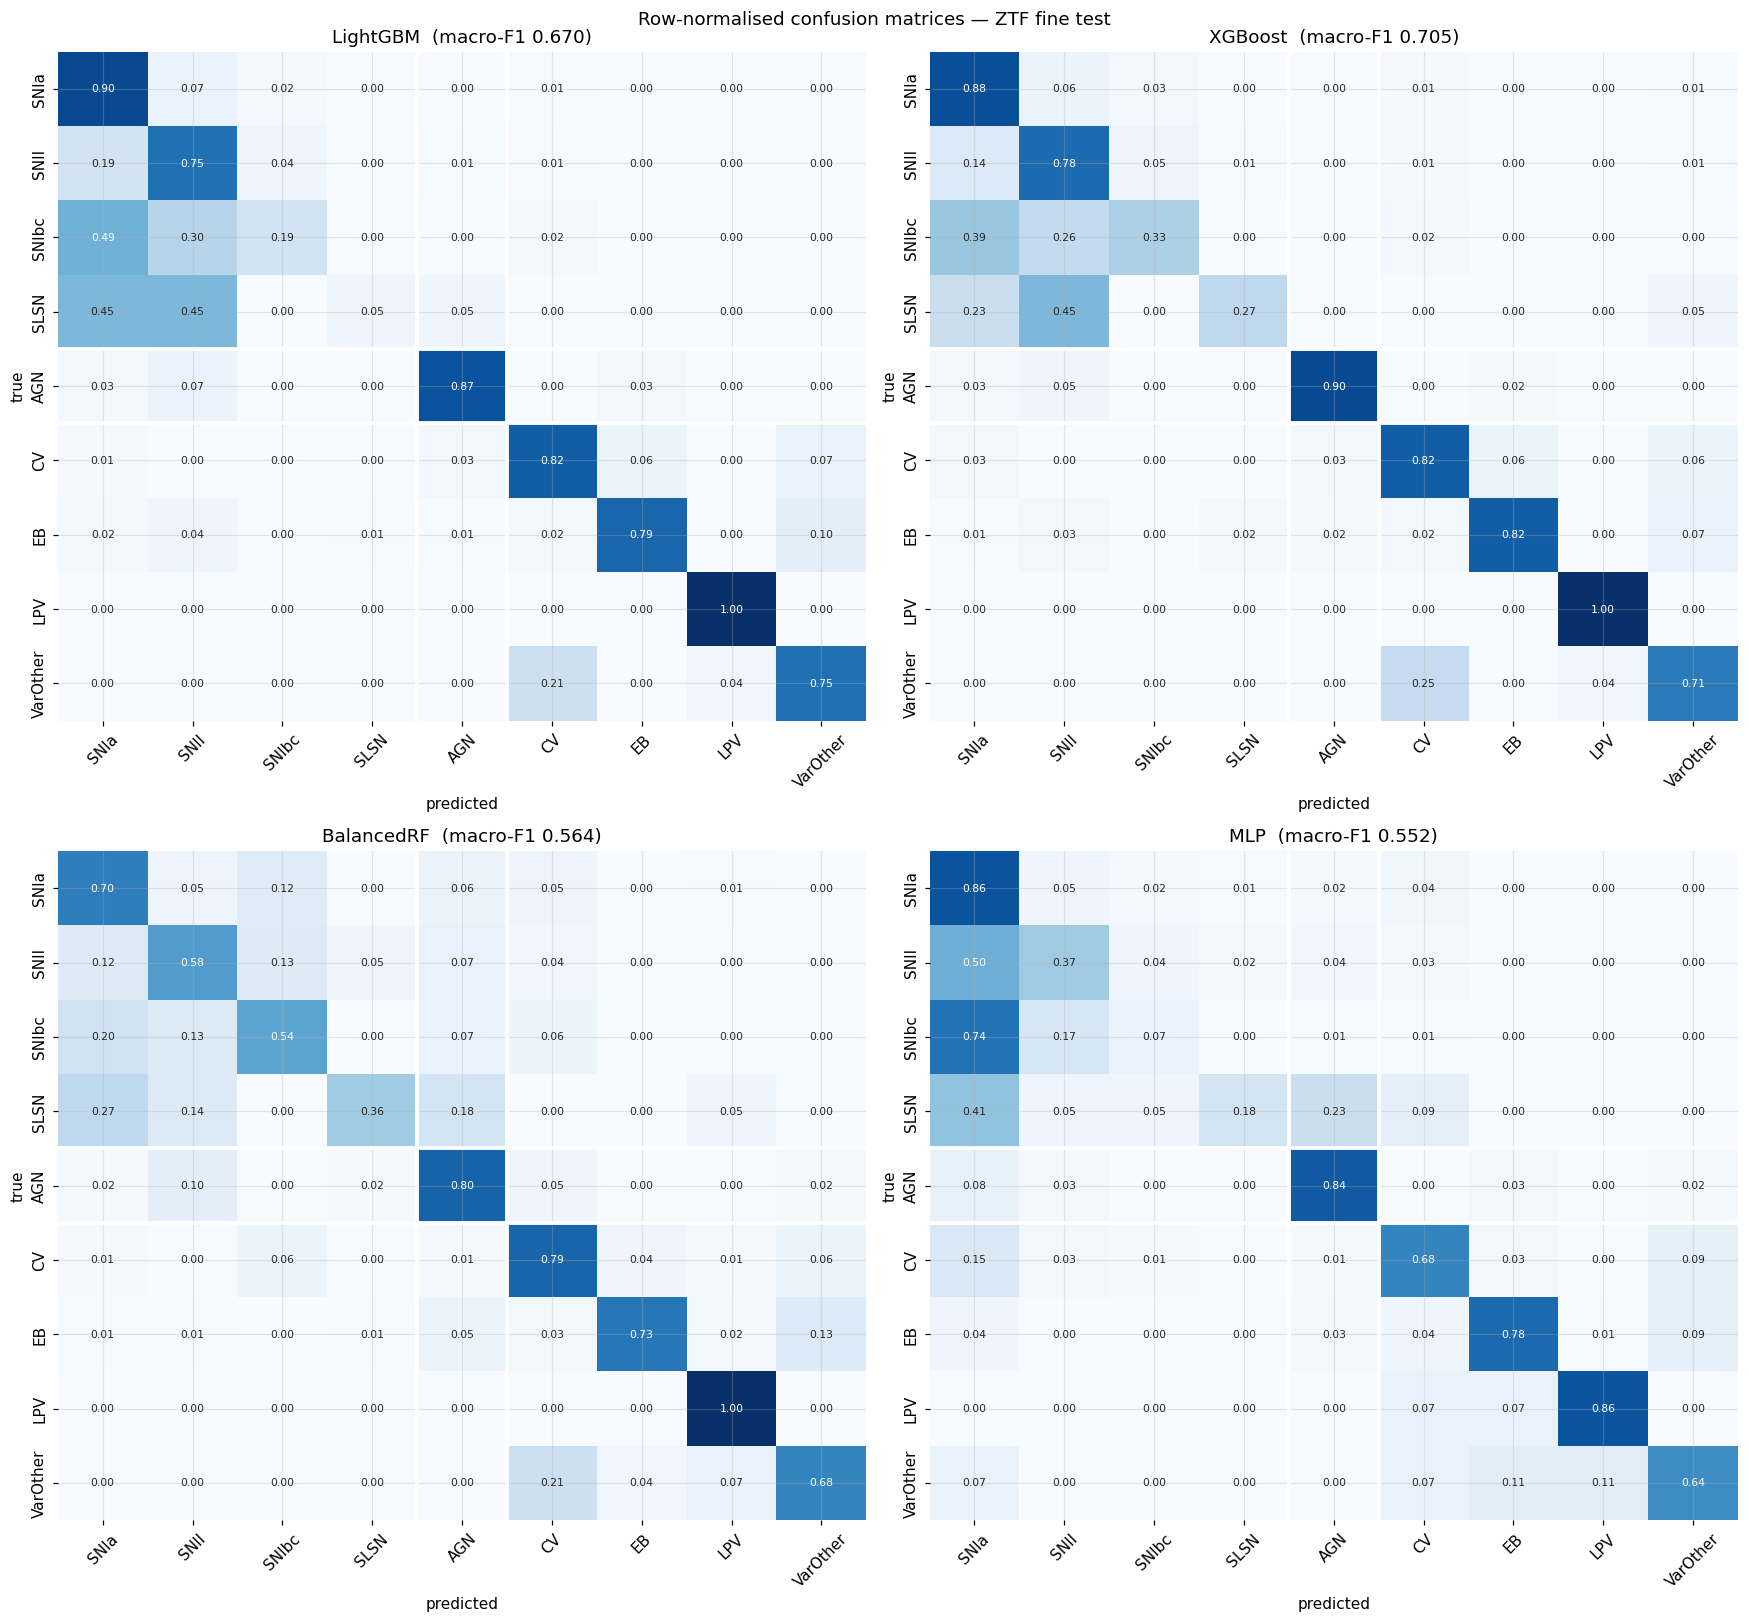

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 15))
for ax, algo in zip(axes.ravel(), ALGORITHMS):
    sns.heatmap(test_evals[algo]["confusion_norm"], annot=True, fmt=".2f", cmap="Blues",
                vmin=0, vmax=1, xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=False, annot_kws={"size": 7})
    for b in (4, 5):                      # SN | AGN | VS family boundaries
        ax.axhline(b, color="white", lw=2.5); ax.axvline(b, color="white", lw=2.5)
    ax.set_title(f"{ALGO_LABELS[algo]}  (macro-F1 {test_evals[algo]['macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Row-normalised confusion matrices — ZTF fine test"); fig.tight_layout()
savefig(fig, "08_confusion_grid"); plt.show()

## 6.3 Per-class F1 (algorithms × classes)

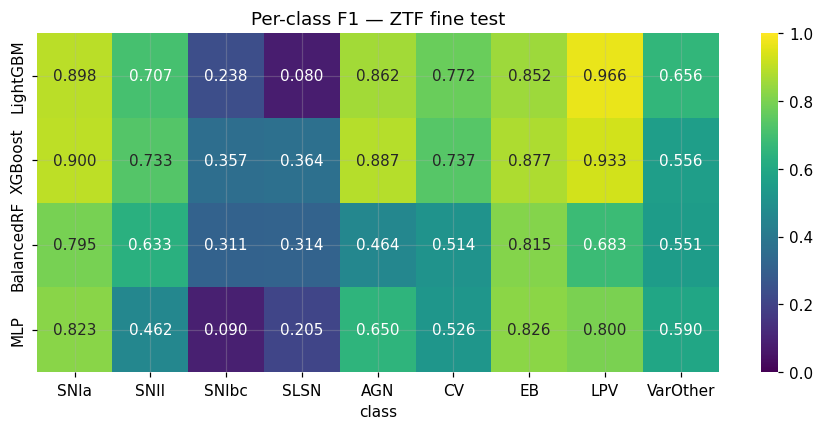

In [28]:
f1mat = pd.DataFrame({ALGO_LABELS[a]: test_evals[a]["per_class"]["f1"] for a in ALGORITHMS}).T
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(f1mat, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1, ax=ax)
ax.set_title("Per-class F1 — ZTF fine test"); ax.set_xlabel("class"); ax.set_ylabel("")
savefig(fig, "09_perclass_f1"); plt.show()

**Observations.**
- The columns to watch are the rare ones — **SLSN, LPV, VarOther** — and the
  physically-confusable **SNIbc** (stripped-envelope SNe sit between SNIa and
  SNII in light-curve shape). The dominant classes (SNIa, EB) are easy for every
  algorithm, so the macro-F1 ranking is decided in the tail.

## 6.4 ROC and precision–recall (micro-averaged over classes)

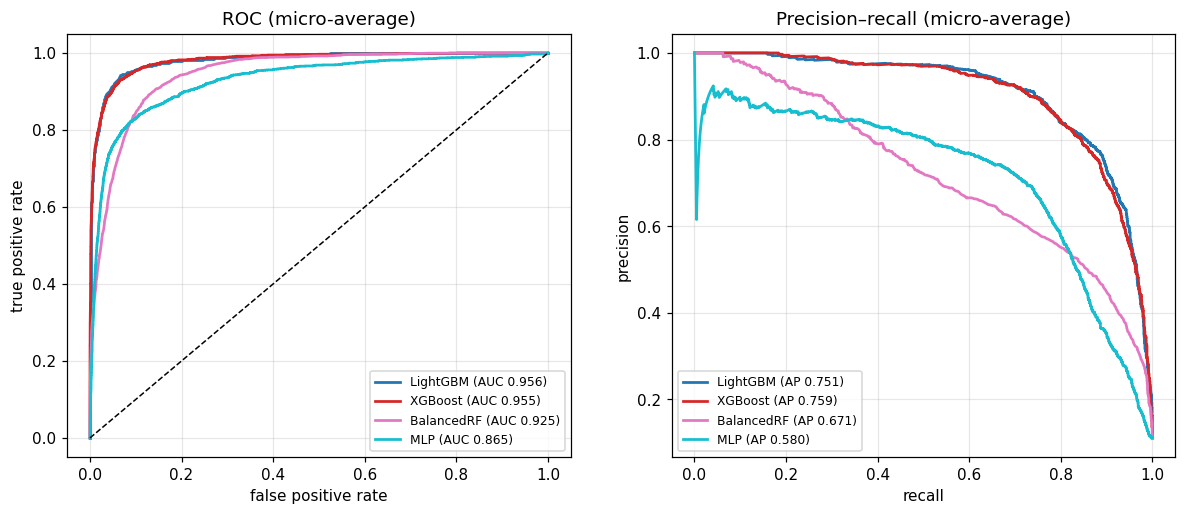

In [29]:
Yte_bin = label_binarize(yte, classes=range(len(CLASSES)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(ALGORITHMS)))
for color, algo in zip(colors, ALGORITHMS):
    proba = best_models[algo].predict_proba(Xte)
    fpr, tpr, _ = roc_curve(Yte_bin.ravel(), proba.ravel())
    axes[0].plot(fpr, tpr, color=color, lw=1.8,
                 label=f"{ALGO_LABELS[algo]} (AUC {test_evals[algo]['roc_auc_macro']:.3f})")
    prec, rec, _ = precision_recall_curve(Yte_bin.ravel(), proba.ravel())
    axes[1].plot(rec, prec, color=color, lw=1.8,
                 label=f"{ALGO_LABELS[algo]} (AP {test_evals[algo]['pr_auc_macro']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC (micro-average)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision–recall (micro-average)"); axes[1].legend(fontsize=8)
savefig(fig, "10_roc_pr"); plt.show()

## 6.5 Feature-importance agreement

If two very different learners rest their decisions on the *same* features, we can
trust those features are real signal rather than an artefact of one algorithm.
Here we compare LightGBM split-gain importance against BRF permutation importance.

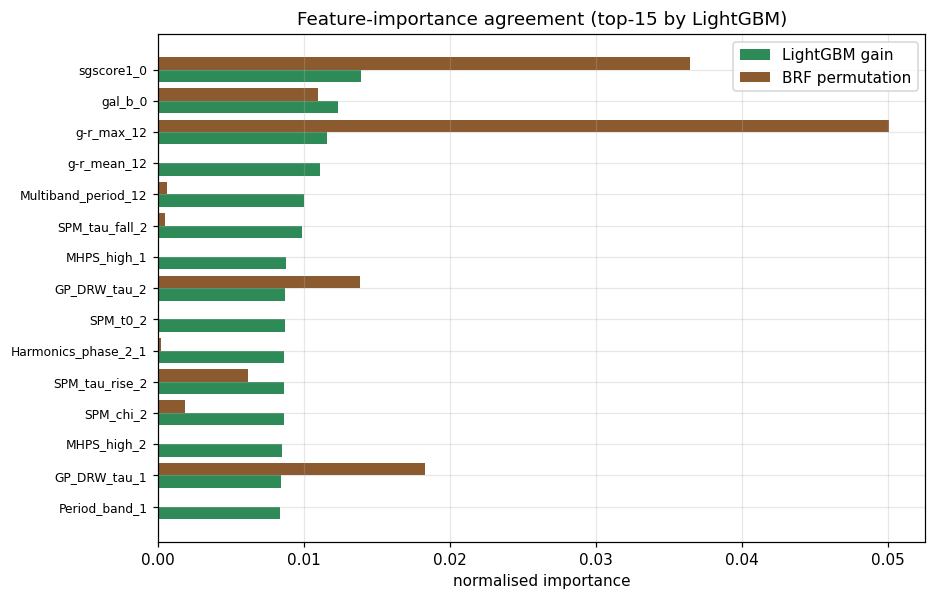

top-20 feature overlap between LightGBM and BRF: 3/20


In [30]:
lgb_imp = pd.Series(best_models["lightgbm"].feature_importances_, index=FEATURES)
lgb_imp = lgb_imp / lgb_imp.sum()

# permutation importance for BRF on a val subsample (permutation is expensive)
rng = np.random.default_rng(SEED)
sub = rng.choice(len(Xva), size=min(600, len(Xva)), replace=False)
pi = permutation_importance(best_models["brf"], Xva.iloc[sub], yva[sub],
                            n_repeats=5, random_state=SEED, scoring="f1_macro", n_jobs=-1)
brf_imp = pd.Series(pi.importances_mean, index=FEATURES).clip(lower=0)
brf_imp = brf_imp / (brf_imp.sum() or 1)

imp = pd.DataFrame({"LightGBM_gain": lgb_imp, "BRF_perm": brf_imp})
topn = imp["LightGBM_gain"].sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(9, 6))
ys, w = np.arange(len(topn)), 0.4
ax.barh(ys + w / 2, imp.loc[topn, "LightGBM_gain"], w, label="LightGBM gain", color="#2e8b57")
ax.barh(ys - w / 2, imp.loc[topn, "BRF_perm"], w, label="BRF permutation", color="#8b5a2e")
ax.set_yticks(ys); ax.set_yticklabels(topn, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("normalised importance")
ax.set_title("Feature-importance agreement (top-15 by LightGBM)"); ax.legend()
savefig(fig, "11_feature_importance"); plt.show()

overlap = len(set(imp["LightGBM_gain"].nlargest(20).index) & set(imp["BRF_perm"].nlargest(20).index))
print(f"top-20 feature overlap between LightGBM and BRF: {overlap}/20")

## 6.6 Inference latency

In [31]:
lat_df = pd.DataFrame(latency).set_index("model").round(4)
lat_df.to_csv(FIGDIR / "latency.csv")
lat_df

,per_object_ms
model,
LightGBM,0.0130
XGBoost,0.0234
BalancedRF,0.0660
MLP,0.0074


## 6.7 Per-class F1 vs training-set size — the rare-class tail

The same diagnostic the PLAsTiCC notebook uses on its native 14-class task: if
test F1 rises with training support, performance in the tail is data-limited
rather than model-limited — the honest framing for the thesis's sub-typing
stretch objective.

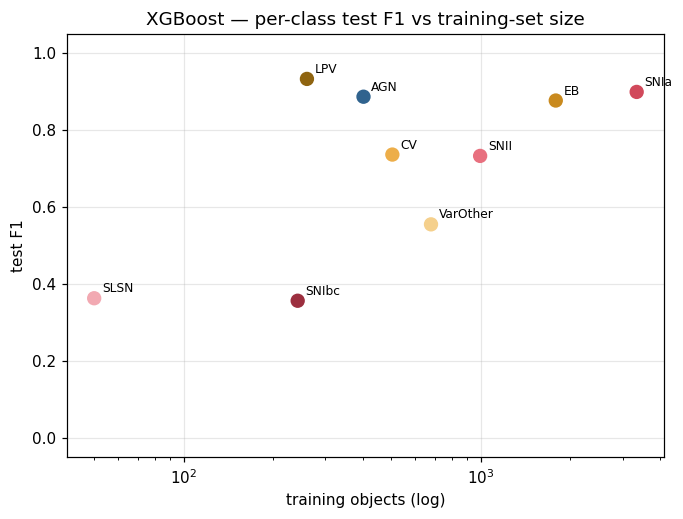

In [32]:
lead_label = test_df["macro_f1"].idxmax()
lead = {v: k for k, v in ALGO_LABELS.items()}[lead_label]
train_counts = pd.Series(ytr).value_counts().reindex(range(len(CLASSES)), fill_value=0)
pcf1 = test_evals[lead]["per_class"]["f1"].values
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_counts.values, pcf1, s=70, color=[FINE_COLORS[c] for c in CLASSES], zorder=3)
for i, c in enumerate(CLASSES):
    ax.annotate(c, (train_counts.values[i], pcf1[i]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("training objects (log)")
ax.set_ylabel("test F1"); ax.set_ylim(-0.05, 1.05)
ax.set_title(f"{lead_label} — per-class test F1 vs training-set size")
savefig(fig, "12_perclass_f1_vs_trainsize"); plt.show()

## 6.8 Verdict

In [33]:
winner = test_df["macro_f1"].idxmax()
winner_algo = {v: k for k, v in ALGO_LABELS.items()}[winner]
print(f"Best ZTF fine (9-class) light-curve model by test macro-F1: {winner} "
      f"({test_df.loc[winner, 'macro_f1']:.3f})")
print(f"-> saved under {MODELDIR / winner_algo}")
summary = test_df.copy()
summary["is_winner"] = summary.index == winner
summary.to_csv(FIGDIR / "verdict.csv")
summary

Best ZTF fine (9-class) light-curve model by test macro-F1: XGBoost (0.705)
-> saved under models\lc\ztf_fine\xgboost


,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss,is_winner
model,,,,,,,,,
LightGBM,0.6701,0.6801,0.8175,0.6855,0.8090,0.9558,0.7506,0.5274,False
XGBoost,0.7049,0.7255,0.8226,0.7028,0.8230,0.9552,0.7588,0.5493,True
BalancedRF,0.5645,0.6877,0.6774,0.5371,0.7100,0.9253,0.6712,1.1480,False
MLP,0.5523,0.5861,0.7107,0.4905,0.6932,0.8654,0.5795,3.5276,False


# 7. Hierarchical coarse→fine comparison

The ALeRCE production light-curve classifier is *hierarchical*: a top-level model
picks the coarse branch, then per-branch models resolve the subtype. This section
builds that architecture from the same data and compares it against the flat
winner on the identical test fold. Probabilities are combined by chaining:

$$P(\text{fine}) = P(\text{coarse}) \cdot P(\text{fine} \mid \text{coarse})$$

Three design decisions, stated up front:

- **Stage-1 is retrained in this notebook**, not loaded from `models/lc/ztf/`:
  the fine object set (19 generic-SN objects dropped) and the recomputed
  dead-feature set differ slightly from the coarse notebook's, and the comparison
  is only clean if both competitors see identical data. We still reuse the coarse
  notebook's *tuning effort* by loading its `best_params.json` — zero extra
  Optuna cost.
- **Branch models reuse the flat winner's tuned hyper-parameters.** A per-branch
  re-tune would tune against even thinner val slices than §5.3 warns about; this
  is noted as future work.
- **Winner family only.** The hierarchy is built with the §6 winning algorithm;
  running all four would quadruple the section for little methodological gain.
- The **AGN branch has a single fine class**, so $P(\text{fine}\mid\text{AGN})=1$
  and no model is needed — the coarse AGN probability passes through unchanged.

In [34]:
# --- 7.1 Stage-1: coarse SN/AGN/VS model, reusing the coarse notebook's tuning
coarse_params = json.loads((COARSE_MODELDIR / winner_algo / "best_params.json").read_text())
if winner_algo == "xgboost":
    coarse_params["num_class"] = len(COARSE_CLASSES)

y_coarse_tr = y_coarse[masks["train"]]
y_coarse_va = y_coarse[masks["val"]]
y_coarse_te = y_coarse[masks["test"]]
y_coarse_trval = np.concatenate([y_coarse_tr, y_coarse_va])

stage1_vm = fit_model(make_model(winner_algo, coarse_params), winner_algo,
                      Xtr, y_coarse_tr, Xva, y_coarse_va)
stage1_val_ev = evaluate(y_coarse_va, stage1_vm.predict_proba(Xva), class_names=COARSE_CLASSES)
stage1 = fit_model(make_model(winner_algo, coarse_params), winner_algo, Xtrval, y_coarse_trval)
print(f"stage-1 ({ALGO_LABELS[winner_algo]}) coarse val macro-F1: {stage1_val_ev['macro_f1']:.3f}")

stage-1 (XGBoost) coarse val macro-F1: 0.928


In [35]:
# --- 7.2 Branch models (explicit class lists — never derived from np.unique)
BRANCHES = {"SN": CLASSES[0:4], "VS": CLASSES[5:9]}   # AGN: single class, no model
assert BRANCHES["SN"] == ["SNIa", "SNII", "SNIbc", "SLSN"]
assert BRANCHES["VS"] == ["CV", "EB", "LPV", "VarOther"]

branch_models, branch_val_evs, branch_params = {}, {}, {}
for parent, bclasses in BRANCHES.items():
    bidx = {c: i for i, c in enumerate(bclasses)}
    inb  = (df["coarse"] == parent).to_numpy()
    m_tr, m_va = masks["train"] & inb, masks["val"] & inb
    Xtr_b, ytr_b = X[m_tr], df.loc[m_tr, "fine_grouped"].map(bidx).to_numpy()
    Xva_b, yva_b = X[m_va], df.loc[m_va, "fine_grouped"].map(bidx).to_numpy()

    bparams = dict(best_params[winner_algo])          # reuse the flat winner's tuning
    if winner_algo == "xgboost":
        bparams["num_class"] = len(bclasses)
    branch_params[parent] = bparams

    vm = fit_model(make_model(winner_algo, bparams), winner_algo, Xtr_b, ytr_b, Xva_b, yva_b)
    branch_val_evs[parent] = evaluate(yva_b, vm.predict_proba(Xva_b), class_names=bclasses)
    Xtrval_b = pd.concat([Xtr_b, Xva_b]); ytrval_b = np.concatenate([ytr_b, yva_b])
    branch_models[parent] = fit_model(make_model(winner_algo, bparams), winner_algo,
                                      Xtrval_b, ytrval_b)
    print(f"{parent} branch ({len(bclasses)} classes, {int(m_tr.sum())} train objects): "
          f"val macro-F1 {branch_val_evs[parent]['macro_f1']:.3f}")

SN branch (4 classes, 4634 train objects): val macro-F1 0.533


VS branch (4 classes, 3232 train objects): val macro-F1 0.639


In [36]:
# --- 7.3 Probability chaining: P(fine) = P(coarse) * P(fine|coarse)
t0 = time.perf_counter()
P_coarse = stage1.predict_proba(Xte)                  # (n, 3) in COARSE_CLASSES order
P_sn     = branch_models["SN"].predict_proba(Xte)     # conditionals for ALL test rows,
P_vs     = branch_models["VS"].predict_proba(Xte)     # not just the routed ones
proba_hier = np.zeros((len(Xte), len(CLASSES)))
proba_hier[:, 0:4] = P_coarse[:, [0]] * P_sn
proba_hier[:, 4]   = P_coarse[:, 1]                   # AGN: single fine class
proba_hier[:, 5:9] = P_coarse[:, [2]] * P_vs
hier_latency_ms = 1e3 * (time.perf_counter() - t0) / len(Xte)
assert np.allclose(proba_hier.sum(1), 1.0), "chained probabilities must sum to 1"
print(f"chained OK — composite latency {hier_latency_ms:.4f} ms/object "
      f"(stage-1 + both branches)")

chained OK — composite latency 0.0379 ms/object (stage-1 + both branches)


In [37]:
# --- 7.4 Single test evaluation, same metric battery as the flat models
ev_hier = evaluate(yte, proba_hier)                   # 9-class defaults are correct here
ev_flat = test_evals[winner_algo]
stage1_test_ev = evaluate(y_coarse_te, P_coarse, class_names=COARSE_CLASSES)

# hard routing (argmax coarse, then argmax within the routed branch) as a reference
pred_hard = np.empty(len(Xte), dtype=int)
cp = P_coarse.argmax(1)
pred_hard[cp == 0] = P_sn[cp == 0].argmax(1)          # SN family -> columns 0..3
pred_hard[cp == 1] = 4                                # AGN
pred_hard[cp == 2] = 5 + P_vs[cp == 2].argmax(1)      # VS family -> columns 5..8
hard_f1 = f1_score(yte, pred_hard, average="macro",
                   labels=list(range(len(CLASSES))), zero_division=0)

hier_df = pd.DataFrame([scalar_row(ev_flat, f"flat_{winner_algo}"),
                        scalar_row(ev_hier, f"hierarchical_{winner_algo}")]
                       ).set_index("model").round(4)
hier_df.to_csv(FIGDIR / "hierarchy_comparison.csv")
print(f"stage-1 coarse test macro-F1: {stage1_test_ev['macro_f1']:.3f} "
      f"(stage-1 errors propagate into every fine prediction)")
print(f"hard-routing macro-F1 (reference): {hard_f1:.3f}  "
      f"vs probability-chained: {ev_hier['macro_f1']:.3f}")
hier_df

stage-1 coarse test macro-F1: 0.944 (stage-1 errors propagate into every fine prediction)
hard-routing macro-F1 (reference): 0.707  vs probability-chained: 0.706


,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
flat_xgboost,0.7049,0.7255,0.8226,0.7028,0.8230,0.9552,0.7588,0.5493
hierarchical_xgboost,0.7059,0.6987,0.8401,0.7227,0.8325,0.9616,0.7757,0.4918


## 7.5 Hierarchical vs flat — figures

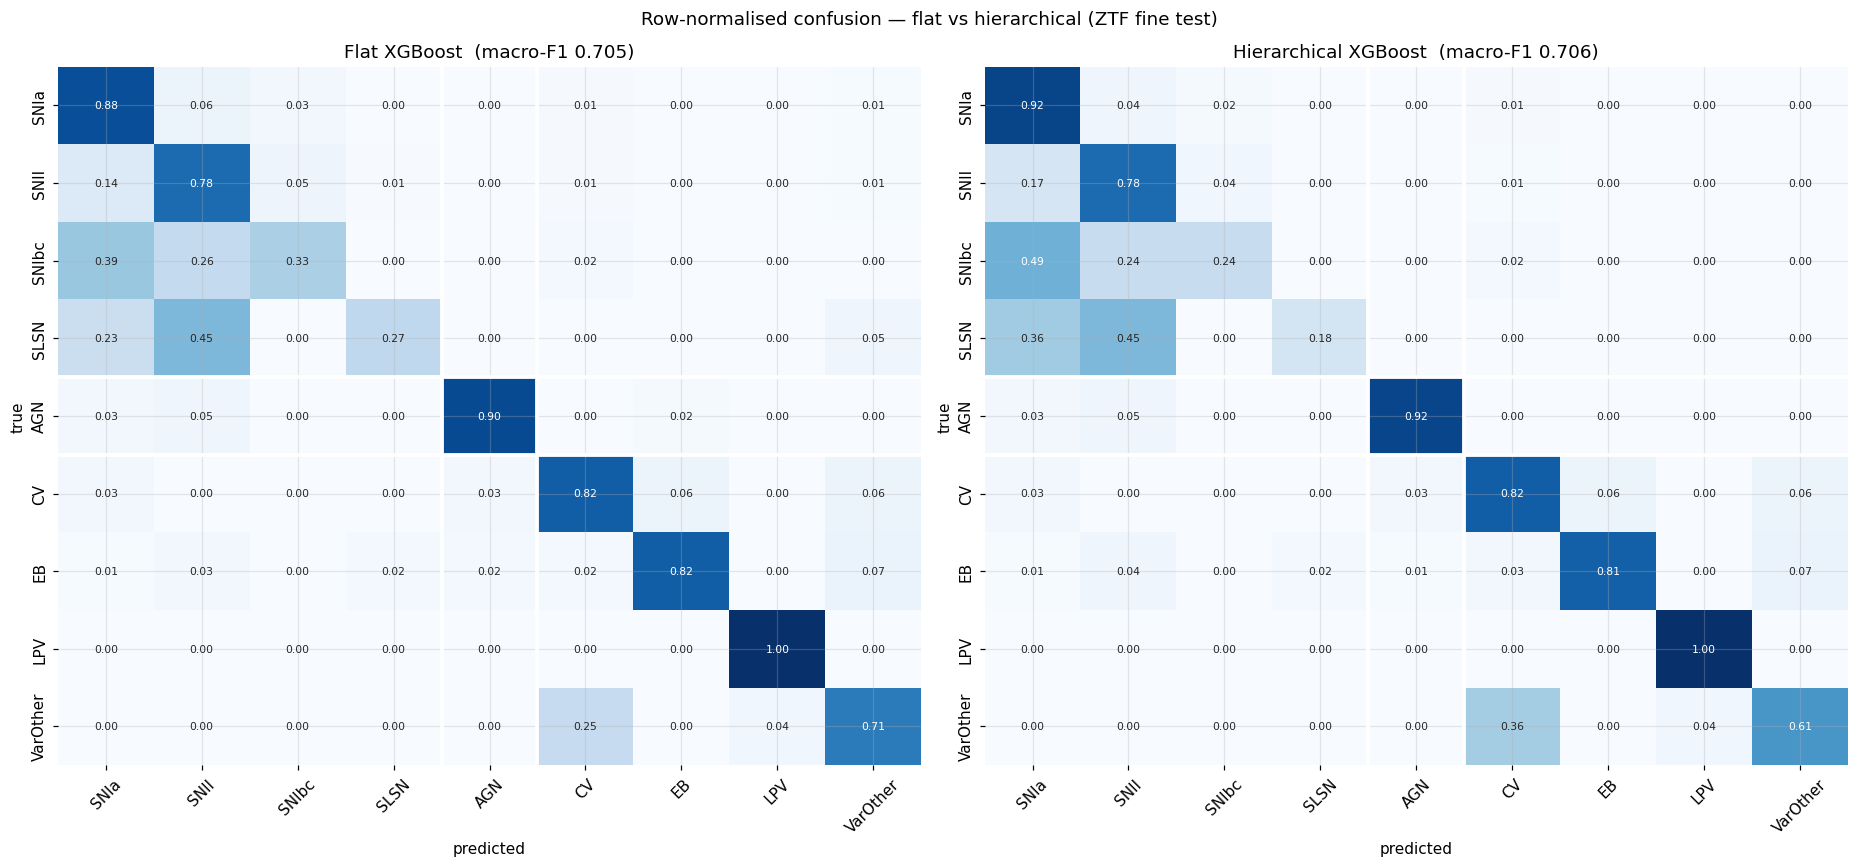

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, (ttl, ev) in zip(axes, [(f"Flat {ALGO_LABELS[winner_algo]}", ev_flat),
                                (f"Hierarchical {ALGO_LABELS[winner_algo]}", ev_hier)]):
    sns.heatmap(ev["confusion_norm"], annot=True, fmt=".2f", cmap="Blues",
                vmin=0, vmax=1, xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=False, annot_kws={"size": 7})
    for b in (4, 5):
        ax.axhline(b, color="white", lw=2.5); ax.axvline(b, color="white", lw=2.5)
    ax.set_title(f"{ttl}  (macro-F1 {ev['macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Row-normalised confusion — flat vs hierarchical (ZTF fine test)")
fig.tight_layout()
savefig(fig, "13_hierarchy_confusion"); plt.show()

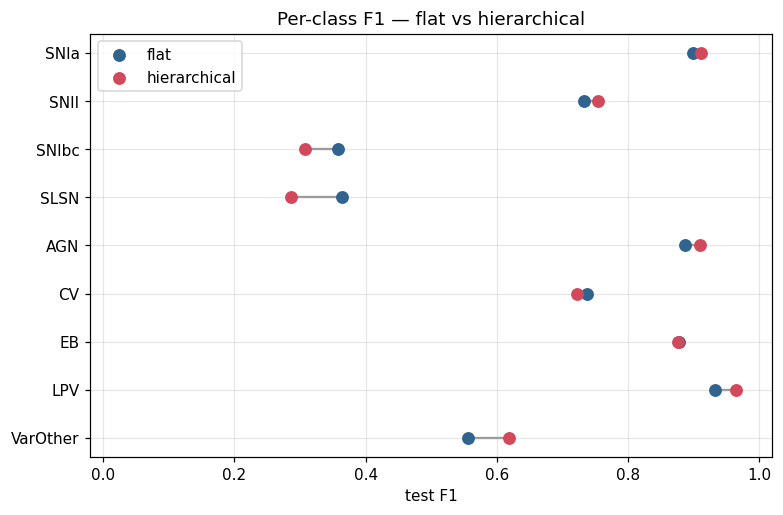

In [39]:
f1_flat = ev_flat["per_class"]["f1"]
f1_hier = ev_hier["per_class"]["f1"]
fig, ax = plt.subplots(figsize=(8, 5))
ys = np.arange(len(CLASSES))
for i, c in enumerate(CLASSES):
    ax.plot([f1_flat[c], f1_hier[c]], [i, i], "-", color="#999999", lw=1.5, zorder=1)
ax.scatter(f1_flat.values, ys, s=55, color="#30638e", label="flat", zorder=2)
ax.scatter(f1_hier.values, ys, s=55, color="#d1495b", label="hierarchical", zorder=2)
ax.set_yticks(ys); ax.set_yticklabels(CLASSES); ax.invert_yaxis()
ax.set_xlim(-0.02, 1.02); ax.set_xlabel("test F1")
ax.set_title("Per-class F1 — flat vs hierarchical"); ax.legend()
savefig(fig, "14_hierarchy_perclass_delta"); plt.show()

## 7.6 Persist the hierarchical composite

Each component gets the standard contract under
`models/lc/ztf_fine/hierarchical/<component>/`, plus a top-level
`hierarchy_card.json` that records the wiring (which directory serves which
branch, the chaining formula) and the composite test metrics — so the fusion
notebook or alert system can load the whole hierarchy from one file.

In [40]:
def save_hier_component(subdir, model, role, class_names, params, val_ev, provenance):
    outdir = MODELDIR / "hierarchical" / subdir
    outdir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, outdir / "model.joblib")
    native = None
    if winner_algo == "lightgbm":
        model.booster_.save_model(str(outdir / "model.txt")); native = "model.txt"
    elif winner_algo == "xgboost":
        model.get_booster().save_model(str(outdir / "model.json")); native = "model.json"
    card = {"algorithm": winner_algo, "dataset": "ztf", "taxonomy": "fine_grouped",
            "role": role, "class_names": class_names, "n_classes": len(class_names),
            "feature_names": FEATURES, "n_features": len(FEATURES),
            "chaining": "P(fine) = P(coarse) * P(fine|coarse)",
            "params_provenance": provenance, "tuned_params": params,
            "consumes_nan_natively": winner_algo in ("lightgbm", "xgboost"),
            "split_hash": SPLIT_HASH, "coarse_split_hash": COARSE_SPLIT_HASH,
            "train_date": RUN_DATE, "native_model": native,
            "val_metrics": scalar_metrics(val_ev),
            "package_versions": package_versions()}
    (outdir / "model_card.json").write_text(json.dumps(card, indent=2))
    (outdir / "best_params.json").write_text(json.dumps(params, indent=2))

save_hier_component("stage1_coarse", stage1, "stage1_coarse", COARSE_CLASSES,
                    coarse_params, stage1_val_ev,
                    f"reused models/lc/ztf/{winner_algo}/best_params.json")
save_hier_component("sn_branch", branch_models["SN"], "branch_sn", BRANCHES["SN"],
                    branch_params["SN"], branch_val_evs["SN"],
                    "reused flat fine winner's tuned params")
save_hier_component("vs_branch", branch_models["VS"], "branch_vs", BRANCHES["VS"],
                    branch_params["VS"], branch_val_evs["VS"],
                    "reused flat fine winner's tuned params")

hier_card = {
    "architecture": "hierarchical coarse->fine",
    "algorithm": winner_algo,
    "stage1": {"dir": "stage1_coarse", "classes": COARSE_CLASSES},
    "branches": {"SN":  {"dir": "sn_branch", "classes": BRANCHES["SN"]},
                 "AGN": {"dir": None, "classes": ["AGN"],
                         "note": "single fine class, P(fine|AGN)=1"},
                 "VS":  {"dir": "vs_branch", "classes": BRANCHES["VS"]}},
    "class_names": CLASSES,
    "chaining": "P(fine) = P(coarse) * P(fine|coarse); "
                "branch conditionals are predicted for all objects",
    "test_metrics": scalar_metrics(ev_hier),
    "stage1_coarse_test_metrics": scalar_metrics(stage1_test_ev),
    "flat_winner_test_macro_f1": float(ev_flat["macro_f1"]),
    "hard_routing_test_macro_f1": float(hard_f1),
    "latency_ms_per_object": float(hier_latency_ms),
    "split_hash": SPLIT_HASH, "coarse_split_hash": COARSE_SPLIT_HASH,
    "train_date": RUN_DATE,
}
(MODELDIR / "hierarchical" / "hierarchy_card.json").write_text(json.dumps(hier_card, indent=2))
print(f"saved hierarchical composite under {MODELDIR / 'hierarchical'}")

saved hierarchical composite under models\lc\ztf_fine\hierarchical


# 8. Summary

- The fine 9-class task is decided in the **rare-class tail**: the dominant
  classes (SNIa, EB) are easy for every algorithm, so macro-F1 ranks the models
  by SLSN / LPV / VarOther / SNIbc performance — exactly the sub-typing frontier
  the stretch objective was meant to probe. Figure `12_perclass_f1_vs_trainsize`
  shows how much of the tail is data-limited rather than model-limited.
- The **grouped taxonomy is a documented decision, not a convenience**: the raw
  25-class fine labels leave several classes with zero val/test objects under the
  deployment-faithful temporal split. The grouping (stored verbatim as `fine_map`
  in every model card) is what makes the task evaluable at all.
- The **thin-class tuning caveat** (§5.3) is the honest price of the temporal
  protocol: LPV and EB contribute quantised noise to the tuning objective. It is
  reported and quantified, not patched by re-stratifying.
- §7 compares the flat winner against an **ALeRCE-style hierarchical** classifier
  built by probability chaining; `figures/lc/ztf_fine/hierarchy_comparison.csv`
  and figure 14 show where the coarse-first decomposition helps or hurts per class.
- All models ship with full model cards (feature order, class order, taxonomy
  map, both split hashes) under `models/lc/ztf_fine/`. The companion write-up is
  `docs/lc_classifier_ztf_fine.md`.